In [1]:
import torch
from d2l import torch as d2l

#### 4.4.1 The Softmax

In [2]:
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdims=True), X.sum(1, keepdims=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [3]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdims=True)
    return X_exp / partition  # The broadcasting mechanism is applied here

In [4]:
X = torch.rand((2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.1747, 0.2584, 0.1267, 0.2442, 0.1960],
         [0.2246, 0.1757, 0.2266, 0.1733, 0.1998]]),
 tensor([1.0000, 1.0000]))

#### 4.4.2 The Model

In [5]:
class SoftmaxRegressionScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs),
                              requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)

    def parameters(self):
        return [self.W, self.b]

In [6]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def forward(self, X):
    X = X.reshape((-1, self.W.shape[0]))
    return softmax(torch.matmul(X, self.W) + self.b)

#### 4.4.3 The Cross-Entropy Loss

In [7]:
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]

tensor([0.1000, 0.5000])

In [8]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[list(range(len(y_hat))), y]).mean()

cross_entropy(y_hat, y)

tensor(1.4979)

In [9]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def loss(self, y_hat, y):
    return cross_entropy(y_hat, y)

#### 4.4.4 Training

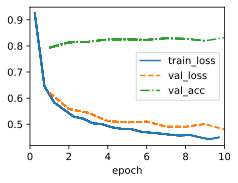

In [10]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

#### 4.4.5 Prediction

In [11]:
X, y = next(iter(data.val_dataloader()))
preds = model(X).argmax(axis=1)
preds.shape

torch.Size([256])

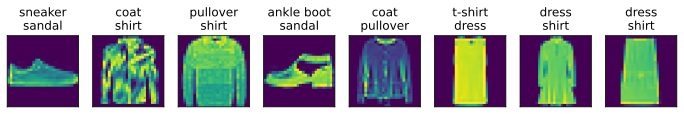

In [12]:
wrong = preds.type(y.dtype) != y
X, y, preds = X[wrong], y[wrong], preds[wrong]
labels = [a+'\n'+b for a, b in zip(
    data.text_labels(y), data.text_labels(preds))]
data.visualize([X, y], labels=labels)

In [ ]:
# exercise_1_1
exe_1 = torch.rand((1, 100))
softmax(exe_1)

tensor([[0.0079, 0.0102, 0.0076, 0.0159, 0.0083, 0.0090, 0.0115, 0.0088, 0.0079,
         0.0113, 0.0078, 0.0070, 0.0074, 0.0100, 0.0144, 0.0083, 0.0062, 0.0154,
         0.0156, 0.0071, 0.0128, 0.0077, 0.0086, 0.0078, 0.0061, 0.0150, 0.0148,
         0.0103, 0.0077, 0.0064, 0.0079, 0.0117, 0.0110, 0.0060, 0.0124, 0.0103,
         0.0101, 0.0069, 0.0065, 0.0073, 0.0078, 0.0131, 0.0146, 0.0112, 0.0073,
         0.0126, 0.0081, 0.0116, 0.0111, 0.0091, 0.0082, 0.0102, 0.0120, 0.0101,
         0.0131, 0.0075, 0.0073, 0.0093, 0.0155, 0.0105, 0.0078, 0.0143, 0.0150,
         0.0150, 0.0091, 0.0065, 0.0084, 0.0091, 0.0141, 0.0111, 0.0060, 0.0083,
         0.0087, 0.0095, 0.0081, 0.0102, 0.0062, 0.0091, 0.0069, 0.0113, 0.0091,
         0.0090, 0.0104, 0.0111, 0.0154, 0.0065, 0.0112, 0.0098, 0.0061, 0.0096,
         0.0091, 0.0148, 0.0064, 0.0124, 0.0134, 0.0099, 0.0074, 0.0122, 0.0104,
         0.0155]])

In [ ]:
# exercise_1_2
exe_1_2 = torch.rand((1, 100)) - 100
softmax(exe_1_2)

tensor([[0.0129, 0.0103, 0.0155, 0.0144, 0.0127, 0.0063, 0.0061, 0.0136, 0.0066,
         0.0070, 0.0140, 0.0090, 0.0074, 0.0153, 0.0105, 0.0142, 0.0070, 0.0072,
         0.0138, 0.0059, 0.0099, 0.0070, 0.0112, 0.0144, 0.0088, 0.0096, 0.0077,
         0.0061, 0.0112, 0.0063, 0.0092, 0.0072, 0.0092, 0.0131, 0.0158, 0.0074,
         0.0079, 0.0125, 0.0090, 0.0112, 0.0074, 0.0068, 0.0125, 0.0109, 0.0079,
         0.0077, 0.0079, 0.0066, 0.0070, 0.0158, 0.0081, 0.0072, 0.0107, 0.0079,
         0.0061, 0.0103, 0.0105, 0.0085, 0.0094, 0.0109, 0.0105, 0.0083, 0.0101,
         0.0066, 0.0059, 0.0061, 0.0083, 0.0112, 0.0088, 0.0109, 0.0099, 0.0081,
         0.0138, 0.0092, 0.0120, 0.0123, 0.0085, 0.0079, 0.0083, 0.0155, 0.0144,
         0.0153, 0.0090, 0.0149, 0.0147, 0.0107, 0.0068, 0.0120, 0.0153, 0.0070,
         0.0158, 0.0074, 0.0103, 0.0090, 0.0116, 0.0085, 0.0103, 0.0088, 0.0138,
         0.0074]])

In [15]:
# exercise_1_3
sm = softmax(exe_1_2)
ind = torch.argmax(sm)
ind

tensor(34)

In [22]:
# exercise_2
def my_cross_entropy(y, y_hat):
    loss = -torch.sum(y * torch.log(y_hat))
    return loss.mean()

In [26]:
# exercise_2_1
my_cross_entropy(exe_1, exe_1_2 + 200)

tensor(-221.7688)

#### exercise_2_2
It is calculated elementwise rather than row-wise or colum-wise...?   

Exactly, whill running ```my_cross_entropy``` Python use ```if``` sentenses and ```while``` loops, while ```cross_entropy``` uses vectorial methord.

#### exercise_2_3
We should not abandon it, cause it provide concise cross entropy loss.

#### exercise_2_4
* Attention of domain, the inputs should be positive.

#### exercise_3
Sometimes we need to know the posibility of other choices, especially ones with higher probobility witch is not much lower than the most likely one.   
To address it, we could rewrite the ```argmax()``` sentence to output others. For instance, resort the choices by its probobility and output them accordingly.

#### exercise_4
* A large vocabulary will lead to large amount of calculation while forward propagation, cause the softmax needs to calculate every sample's exponential to produce a result.
* Similarly, there are troubles while progression of back propagation. The final result would not show up until every sample's deviation is calculated.
* Not only the calculation troubles, but the storage uneasy. While calculation, a large amount of mid-data needs to be stored before the whole progression is done.
* As the vocabulary is more than large, the parameter in the model will be a lot, which leads to the complexity of the model and makes the model uneasy to be understand or interpreted.

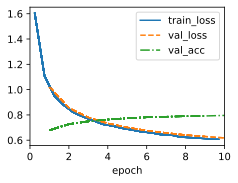

In [27]:
# exercise_5
data_exe_51 = d2l.FashionMNIST(batch_size=256)
model_exe_51 = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.01)
trainer_exe_51 = d2l.Trainer(max_epochs=10)
trainer_exe_51.fit(model_exe_51, data_exe_51)


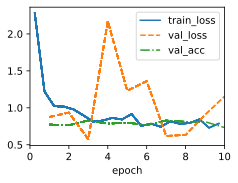

In [28]:
# exercise_5
data_exe_52 = d2l.FashionMNIST(batch_size=256)
model_exe_52 = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.5)
trainer_exe_52 = d2l.Trainer(max_epochs=10)
trainer_exe_52.fit(model_exe_52, data_exe_52)


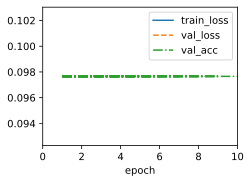

In [29]:
# exercise_5
data_exe_53 = d2l.FashionMNIST(batch_size=256)
model_exe_53 = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=1)
trainer_exe_53 = d2l.Trainer(max_epochs=10)
trainer_exe_53.fit(model_exe_53, data_exe_53)


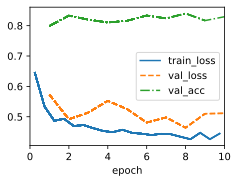

In [31]:
# exercise_5
data_exe_53 = d2l.FashionMNIST(batch_size=256)
model_exe_53 = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.1)
trainer_exe_53 = d2l.Trainer(max_epochs=10)
trainer_exe_53.fit(model_exe_53, data_exe_53)
